# DQN on `CarRacingEnv`

This notebook applies DQN to the project's `CarRacingEnv`, following the
same code shape I used in lab10 for CartPole: an MLP Q-network, a uniform
replay buffer, an epsilon-greedy DQN agent, and a `run_episode_dqn` +
`train(cfg)` pipeline. The shared `train_util.py` carries `set_seed`,
`TrainConfig`, and `EpisodeLogger` — same as lab10, with car-specific
fields added (slippery, reward overrides, early-termination thresholds).

The car env has a 13-D continuous observation, so there's no tabular
stage — straight into the DQN pieces.

**Pipeline:**
1. Q-Network (MLP)
2. Replay Buffer
3. DQN Agent
4. Training pipeline on `slippery=False` (pretrain regime)
5. Evaluation + zero-shot transfer to `slippery=True`

In [14]:
# TODO: Replace with your name and university ID
student_name = "xxx"
student_id = "uxxx"

In [15]:
import sys
import getpass
import math
import random
import time
import pathlib
from collections import deque
from dataclasses import asdict, fields
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from car_env import CarRacingEnv, ACTION_NAMES
from train_util import EpisodeLogger, TrainConfig, set_seed


def is_notebook():
    return 'ipykernel' in sys.modules


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
print("Python Version: {}".format(sys.version))
print("PyTorch Version: {}".format(torch.__version__))
print("Device:", device)

User: Admin (xxx, uxxx)
Python Version: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
PyTorch Version: 2.11.0+cu130
Device: cuda


## Q-Network

Same MLP shape as lab10. The car observation is 13 floats (7 LIDAR rays
+ 6 extras — `speed`, `fwd_vel`, `lat_vel`, `is_off_road`,
`angle_to_center`), all roughly in `[-1, 1]`, so no normalization layer
is needed.

The action space is `Discrete(6)` by default (the `no_noop` action set:
`Acc`, `Dec`, `LEFT`, `RIGHT`, `Acc+LEFT`, `Acc+RIGHT` — NOOP dropped to
remove the sit-still-at-spawn trap).

In [3]:
class _QNet(nn.Module):
    """
    Simple MLP Q-network: obs -> Q(s, a) for each action.

    Args
    ----
    obs_dim    : observation dimension (input to the Q net).
    n_actions  : number of discrete actions (output of the Q net).
    hidden     : list of hidden layer widths. e.g. [128, 128] gives two
                 hidden layers with 128 units each.

    All activations are ReLU (same as lab10).
    """

    def __init__(self, obs_dim: int, n_actions: int, hidden: list[int]) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        input_dim = obs_dim
        for h in hidden:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            input_dim = h
        layers.append(nn.Linear(input_dim, n_actions))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [4]:
if is_notebook():
    # obs_dim = 7 rays + 6 extras = 13;  n_actions = 6 (no_noop default)
    net = _QNet(obs_dim=13, n_actions=6, hidden=[128, 128])

    linear_layers = [m for m in net.net if isinstance(m, nn.Linear)]
    assert list(linear_layers[0].weight.shape) == [128, 13],         f"Layer 0 weight shape wrong: {list(linear_layers[0].weight.shape)}"
    assert list(linear_layers[1].weight.shape) == [128, 128],         f"Layer 1 weight shape wrong: {list(linear_layers[1].weight.shape)}"
    assert list(linear_layers[2].weight.shape) == [6, 128],         f"Layer 2 weight shape wrong: {list(linear_layers[2].weight.shape)}"
    print("All layer dimension checks passed!")

    dummy = torch.zeros(1, 13)
    out = net(dummy)
    assert out.shape == (1, 6), f"Output shape wrong: {list(out.shape)}"
    print("Output shape check passed!")

All layer dimension checks passed!
Output shape check passed!


## Replay Buffer

Identical interface to lab10. Sequential interactions in the car env are
highly correlated (the car's position changes by `vel` each step), so we
sample uniformly from a fixed-capacity deque to break that correlation.

In [5]:
class ReplayBuffer:
    """Fixed-capacity circular buffer storing (s, a, r, s', done) tuples.

    Sampling is uniform-random (standard DQN). Same shape as lab10's
    buffer; the only thing that changes is the obs dimension.
    """

    def __init__(self, capacity: int = 100_000) -> None:
        self.buffer: deque = deque(maxlen=capacity)

    def push(self, obs, action, reward, next_obs, done) -> None:
        data = (
            np.asarray(obs, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_obs, dtype=np.float32),
            bool(done),
        )
        self.buffer.append(data)

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (
            np.stack(obs),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.stack(next_obs),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self) -> int:
        return len(self.buffer)

In [6]:
if is_notebook():
    obs_dim, n_actions, batch_size = 13, 6, 4

    buf = ReplayBuffer(capacity=100_000)
    for _ in range(10):
        obs      = np.random.randn(obs_dim).astype(np.float32)
        action   = np.random.randint(n_actions)
        reward   = float(np.random.randn())
        next_obs = np.random.randn(obs_dim).astype(np.float32)
        done     = bool(np.random.randint(2))
        buf.push(obs, action, reward, next_obs, done)

    assert len(buf) == 10, f"Buffer length should be 10, got {len(buf)}"
    obs_b, actions_b, rewards_b, next_obs_b, dones_b = buf.sample(batch_size)
    assert obs_b.shape      == (batch_size, obs_dim)
    assert actions_b.shape  == (batch_size,)
    assert rewards_b.shape  == (batch_size,)
    assert next_obs_b.shape == (batch_size, obs_dim)
    assert dones_b.shape    == (batch_size,)
    print("All shape checks passed!")

All shape checks passed!


## DQN Agent

Same recipe as lab10:

$$L(\theta) = \mathbb{E}_{(s,a,r,s')\sim\mathcal D}\bigl[\bigl(r + \gamma\,(1-d)\,\max_{a'} Q(s',a';\,\theta^-) - Q(s,a;\,\theta)\bigr)^2\bigr]$$

- ε-greedy exploration, linear decay from `eps_start` to `eps_end`.
- Two networks: an online net trained via SGD, and a target net synced
  every `target_update_freq` gradient steps to provide stable TD targets.
- Smooth L1 (Huber) loss + grad-norm clipping.

In [7]:
class DQNAgent:
    """Deep Q-Network agent (Mnih et al., 2015). Same shape as lab10's."""

    def __init__(
        self,
        obs_dim: int,
        n_actions: int,
        lr: float = 5e-4,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay_steps: int = 50_000,
        batch_size: int = 64,
        buffer_capacity: int = 100_000,
        target_update_freq: int = 500,
        hidden_sizes: list[int] = [128, 128],
        grad_clip: float = 10.0,
        device: str = "cpu",
    ) -> None:
        self.n_actions          = n_actions
        self.gamma              = gamma
        self.epsilon            = epsilon_start
        self.epsilon_end        = epsilon_end
        self.epsilon_decay      = (epsilon_start - epsilon_end) / epsilon_decay_steps
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.grad_clip          = grad_clip
        self.device             = torch.device(device)

        self.online_net = _QNet(obs_dim, n_actions, list(hidden_sizes)).to(self.device)
        self.target_net = _QNet(obs_dim, n_actions, list(hidden_sizes)).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_capacity)

        self._steps  = 0
        self._last_obs: Optional[np.ndarray] = None
        self._last_action: Optional[int]     = None

    def select_action(self, obs: np.ndarray, greedy: bool = False) -> int:
        """ε-greedy. `greedy=True` always exploits (used for eval/render)."""
        self._last_obs = np.asarray(obs, dtype=np.float32)
        if (not greedy) and random.random() < self.epsilon:
            action = random.randrange(self.n_actions)
        else:
            with torch.no_grad():
                x = torch.as_tensor(self._last_obs, device=self.device).unsqueeze(0)
                action = int(self.online_net(x).argmax(dim=1).item())
        self._last_action = action
        return action

    def store_transition(self, obs, action, reward, next_obs, done) -> None:
        self.buffer.push(obs, action, reward, next_obs, done)

    def update(self) -> dict[str, float]:
        if len(self.buffer) < self.batch_size:
            return {}

        obs, actions, rewards, next_obs, dones = self.buffer.sample(self.batch_size)
        obs_t      = torch.as_tensor(obs,      dtype=torch.float32, device=self.device)
        actions_t  = torch.as_tensor(actions,  dtype=torch.int64,   device=self.device)
        rewards_t  = torch.as_tensor(rewards,  dtype=torch.float32, device=self.device)
        next_obs_t = torch.as_tensor(next_obs, dtype=torch.float32, device=self.device)
        dones_t    = torch.as_tensor(dones,    dtype=torch.float32, device=self.device)

        B = obs_t.shape[0]
        all_q = self.online_net(obs_t)                                     # (B, n_actions)
        q_values = all_q[torch.arange(B, device=self.device), actions_t]   # (B,)

        with torch.no_grad():
            # Double DQN: online net picks the action, target net evaluates it.
            # Reduces Q-overestimation that destabilises training after a
            # breakthrough (the "ep 270 solves, ep 300 collapses" failure mode).
            next_actions = self.online_net(next_obs_t).argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_obs_t).gather(1, next_actions).squeeze(1)
            targets = rewards_t + self.gamma * next_q * (1.0 - dones_t)

        loss = F.smooth_l1_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), self.grad_clip)
        self.optimizer.step()

        self._steps += 1
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)

        if self._steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return {"loss": float(loss.item()), "epsilon": float(self.epsilon), "steps": self._steps}

In [8]:
if is_notebook():
    obs_dim, n_actions, batch_size = 13, 6, 4
    agent = DQNAgent(obs_dim=obs_dim, n_actions=n_actions, batch_size=batch_size, device=str(device))
    for _ in range(10):
        obs      = np.random.randn(obs_dim).astype(np.float32)
        action   = np.random.randint(n_actions)
        reward   = float(np.random.randn())
        next_obs = np.random.randn(obs_dim).astype(np.float32)
        done     = bool(np.random.randint(2))
        agent.store_transition(obs, action, reward, next_obs, done)

    result = agent.update()
    print(f"loss: {result['loss']:.4f}")
    print(f"epsilon: {result['epsilon']:.6f}")
    print(f"steps: {result['steps']}")

loss: 0.6447
epsilon: 0.999981
steps: 1


## Training Pipeline

Same shape as lab10's `run_episode_dqn` + `train(cfg)` pair. Two adjustments:

- We construct `CarRacingEnv(...)` directly instead of `gym.make(env_id)`.
- `EpisodeLogger.record(...)` gets extra car-specific keys (`progress`,
  `finish`, `crash`) so the summary plot can show progress alongside return.

Note: we push `terminated` (not `done`) into the replay buffer. With the
env's `stagnation`/`backward` early-stops now reported as `truncated`
(time-limit), DQN bootstrapping won't get its Q-targets zeroed
incorrectly on those cut-offs.

In [9]:
def run_episode_dqn(env, agent, max_steps):
    """One DQN episode. Pushes every transition, calls update() each step."""
    obs, _ = env.reset()
    total_reward = 0.0
    last_info: dict = {}
    env_info: dict = {}

    for step in range(max_steps):
        action = agent.select_action(obs)
        next_obs, reward, terminated, truncated, env_info = env.step(action)
        done = terminated or truncated

        # DQN bootstraps with `terminated` only -- truncation continues the MDP:
        agent.store_transition(obs, action, float(reward), next_obs, terminated)
        info = agent.update()
        if info:
            last_info = info

        obs = next_obs
        total_reward += float(reward)
        if done:
            break

    last_info["progress"] = env_info.get("progress_pct", 0.0)
    last_info["finish"]   = bool(env_info.get("finish", False))
    last_info["crash"]    = bool(env_info.get("wall_hit", False))
    return total_reward, step + 1, last_info


def make_env(cfg, render_mode=None):
    return CarRacingEnv(
        slippery=cfg.slippery,
        max_steps=cfg.max_steps,
        reward_config=cfg.reward_overrides,
        early_terminate_backward_pct=cfg.early_terminate_backward_pct,
        early_terminate_stagnation_steps=cfg.early_terminate_stagnation_steps,
        align_spawn_to_tangent=cfg.align_spawn_to_tangent,
        action_set=cfg.action_set,
        render_mode=render_mode,
    )


def _save_best(agent, cfg, ep, progress, path):
    """Persist current online-net weights as the new best checkpoint."""
    pathlib.Path(cfg.save_dir).mkdir(exist_ok=True)
    torch.save({
        "q_state_dict":  agent.online_net.state_dict(),
        "cfg":           asdict(cfg),
        "best_progress": float(progress),
        "best_episode":  int(ep),
    }, path)


def train(cfg, best_ckpt_name="dqn_normal_best.pt"):
    """Train DQN. Auto-saves a "best-progress so far" checkpoint each new max."""
    set_seed(cfg.seed)
    bar = "=" * 60
    print()
    print(bar)
    print(f"  Solver : DQN (Double-DQN target, best-ckpt auto-save)")
    print(f"  Env    : CarRacingEnv (slippery={cfg.slippery}, action_set={cfg.action_set})")
    print(f"  Device : {cfg.device}")
    print(bar)
    print()

    render_mode = "human" if cfg.render else None
    env = make_env(cfg, render_mode=render_mode)
    env.reset(seed=cfg.seed)
    env.action_space.seed(cfg.seed)

    obs_dim   = int(np.prod(env.observation_space.shape))
    n_actions = env.action_space.n

    agent = DQNAgent(
        obs_dim             = obs_dim,
        n_actions           = n_actions,
        lr                  = cfg.lr,
        gamma               = cfg.gamma,
        epsilon_start       = cfg.epsilon_start,
        epsilon_end         = cfg.epsilon_end,
        epsilon_decay_steps = cfg.epsilon_decay_steps,
        batch_size          = cfg.batch_size,
        buffer_capacity     = cfg.buffer_capacity,
        target_update_freq  = cfg.target_update_freq,
        hidden_sizes        = list(cfg.hidden_sizes),
        grad_clip           = cfg.grad_clip,
        device              = cfg.device,
    )

    logger = EpisodeLogger(log_every=10)
    best_path = f"{cfg.save_dir}/{best_ckpt_name}"
    best_progress = -1.0

    t0 = time.time()
    try:
        for ep in range(1, cfg.episodes + 1):
            ret, steps, info = run_episode_dqn(env, agent, cfg.max_steps)
            logger.record(ep, ret, steps, info)
            progress = float(info.get("progress", 0.0))
            if progress > best_progress:
                best_progress = progress
                _save_best(agent, cfg, ep, progress, best_path)
                print(f"  [best] ep {ep:>4}: progress {progress*100:.1f}% "
                      f"(saved -> {best_path})")
    finally:
        env.close()

    elapsed = time.time() - t0
    logger.summary()
    print(f"  Training time: {elapsed:.1f}s")
    print(f"  Best progress: {best_progress*100:.1f}% (weights at {best_path})")
    print()
    return agent, logger

### Pretrain on `slippery=False`

We keep the **env's default rewards** (`progress=3, time=-0.05,
off_road=-3, wall_hit=-10, finish=100, centering=-0.5`). Earlier the
notebook zeroed `wall_hit` and `off_road` "to mimic CartPole's setup",
which made standing still strictly better than risking forward motion —
the agent learned a NOOP policy and returns stalled at ~306. With the
defaults back in, time pressure + crash cost force exploration.


  Solver : DQN (Double-DQN target, best-ckpt auto-save)
  Env    : CarRacingEnv (slippery=False, action_set=no_noop)
  Device : cuda

[Ep     1] return=  302.2  avg20=  302.2  steps= 186  progress=  1.3%  loss=4.9220  epsilon=0.9971  steps=123  finish=False  crash=True
  [best] ep    1: progress 1.3% (saved -> checkpoints/dqn_normal_best.pt)
  [best] ep    2: progress 3.6% (saved -> checkpoints/dqn_normal_best.pt)
  [best] ep    3: progress 5.2% (saved -> checkpoints/dqn_normal_best.pt)
  [best] ep    5: progress 11.5% (saved -> checkpoints/dqn_normal_best.pt)
[Ep    10] return= 1477.6  avg20= 1112.1  steps= 250  progress=  6.0%  loss=5.3057  epsilon=0.9440  steps=2356  finish=False  crash=True
  [best] ep   15: progress 11.7% (saved -> checkpoints/dqn_normal_best.pt)
[Ep    20] return= 1110.9  avg20= 1168.1  steps= 158  progress=  4.4%  loss=6.6580  epsilon=0.8949  steps=4427  finish=False  crash=True
[Ep    30] return=  683.4  avg20= 1172.9  steps=  87  progress=  2.8%  loss=4.1731 

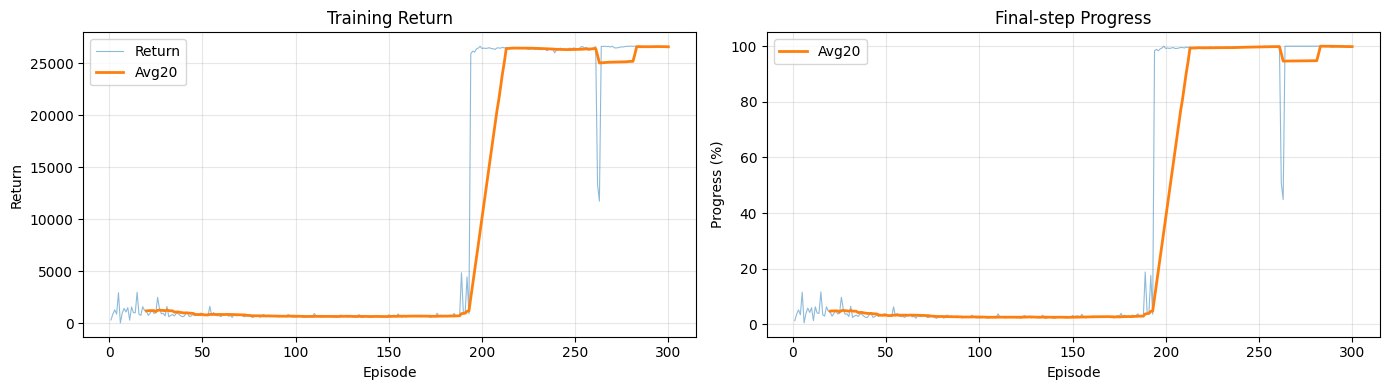

  Training time: 907.1s
  Best progress: 100.0% (weights at checkpoints/dqn_normal_best.pt)



In [11]:
if is_notebook():
    cfg = TrainConfig(
        slippery=False,
        episodes=300,
        max_steps=3000,
        lr=5e-4,
        target_update_freq=500,
        epsilon_decay_steps=40_000,
        device=str(device),
    )
    agent, logger = train(cfg)

### Pretrain with periodic rendered episodes

Same training loop as above, but every 10th episode is rendered to a
pygame window so you can watch the agent learn live. Costs a bit of wall
time on the rendered episode (the 60-FPS cap and event pump are slow
compared to headless), but 9/10 episodes still run headless so total
training throughput stays high.

Run **either** this cell **or** the headless-only cell above — not both,
since both define `agent` and `cfg` that the save / eval cells use.


In [ ]:
def train_mixed(cfg, render_every=10, best_ckpt_name="dqn_normal_best.pt"):
    """Train DQN. Every `render_every`-th episode opens a pygame window.

    Auto-saves a "best-progress so far" checkpoint each time a new max
    is hit -- so post-breakthrough regressions can't lose the peak weights.
    """
    set_seed(cfg.seed)

    env_train  = make_env(cfg, render_mode=None)
    env_render = make_env(cfg, render_mode="human")
    env_train.reset(seed=cfg.seed)
    env_train.action_space.seed(cfg.seed)

    obs_dim   = int(np.prod(env_train.observation_space.shape))
    n_actions = env_train.action_space.n

    agent = DQNAgent(
        obs_dim             = obs_dim,
        n_actions           = n_actions,
        lr                  = cfg.lr,
        gamma               = cfg.gamma,
        epsilon_start       = cfg.epsilon_start,
        epsilon_end         = cfg.epsilon_end,
        epsilon_decay_steps = cfg.epsilon_decay_steps,
        batch_size          = cfg.batch_size,
        buffer_capacity     = cfg.buffer_capacity,
        target_update_freq  = cfg.target_update_freq,
        hidden_sizes        = list(cfg.hidden_sizes),
        grad_clip           = cfg.grad_clip,
        device              = cfg.device,
    )

    logger = EpisodeLogger(log_every=10)
    best_path = f"{cfg.save_dir}/{best_ckpt_name}"
    best_progress = -1.0

    bar = "=" * 60
    print()
    print(bar)
    print(f"  Solver : DQN (Double-DQN, mixed render every {render_every} eps)")
    print(f"  Env    : CarRacingEnv (slippery={cfg.slippery}, action_set={cfg.action_set})")
    print(f"  Device : {cfg.device}")
    print(bar)
    print()

    t0 = time.time()
    try:
        for ep in range(1, cfg.episodes + 1):
            use_render = (ep % render_every == 0)
            env = env_render if use_render else env_train
            ret, steps, info = run_episode_dqn(env, agent, cfg.max_steps)
            info["rendered"] = use_render
            logger.record(ep, ret, steps, info)
            progress = float(info.get("progress", 0.0))
            if progress > best_progress:
                best_progress = progress
                _save_best(agent, cfg, ep, progress, best_path)
                print(f"  [best] ep {ep:>4}: progress {progress*100:.1f}% "
                      f"(saved -> {best_path})")
    finally:
        env_train.close()
        env_render.close()

    elapsed = time.time() - t0
    logger.summary()
    print(f"  Training time: {elapsed:.1f}s")
    print(f"  Best progress: {best_progress*100:.1f}% (weights at {best_path})")
    print()
    return agent, logger


if is_notebook():
    cfg = TrainConfig(
        slippery=False,
        episodes=300,
        max_steps=3000,
        lr=5e-4,
        target_update_freq=500,
        epsilon_decay_steps=40_000,
        device=str(device),
    )
    agent, logger = train_mixed(cfg, render_every=10)


  Solver : DQN (Double-DQN, mixed render every 10 eps)
  Env    : CarRacingEnv (slippery=False, action_set=no_noop)
  Device : cuda

[Ep     1] return=  293.2  avg20=  293.2  steps= 186  progress=  1.3%  loss=4.9450  epsilon=0.9971  steps=123  finish=False  crash=True  rendered=False
  [best] ep    1: progress 1.3% (saved -> checkpoints/dqn_normal_best.pt)
  [best] ep    2: progress 3.6% (saved -> checkpoints/dqn_normal_best.pt)
  [best] ep    3: progress 6.1% (saved -> checkpoints/dqn_normal_best.pt)
  [best] ep    5: progress 6.9% (saved -> checkpoints/dqn_normal_best.pt)


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


[Ep    10] return=  848.7  avg20=  925.2  steps= 127  progress=  3.4%  loss=4.8120  epsilon=0.9480  steps=2190  finish=False  crash=True  rendered=True
  [best] ep   16: progress 12.7% (saved -> checkpoints/dqn_normal_best.pt)
  [best] ep   18: progress 15.2% (saved -> checkpoints/dqn_normal_best.pt)
[Ep    20] return=  876.1  avg20= 1159.8  steps= 180  progress=  3.8%  loss=2.5700  epsilon=0.8876  steps=4732  finish=False  crash=True  rendered=True
  [best] ep   23: progress 17.1% (saved -> checkpoints/dqn_normal_best.pt)
[Ep    30] return=  779.2  avg20= 1350.3  steps= 103  progress=  3.1%  loss=6.0265  epsilon=0.8400  steps=6738  finish=False  crash=True  rendered=True
[Ep    40] return=  821.0  avg20= 1049.2  steps=  86  progress=  3.3%  loss=8.9201  epsilon=0.8152  steps=7783  finish=False  crash=True  rendered=True
[Ep    50] return= 1120.9  avg20=  860.3  steps= 130  progress=  4.4%  loss=4.5968  epsilon=0.7844  steps=9078  finish=False  crash=True  rendered=True
[Ep    60] retu

KeyboardInterrupt: 

### Save checkpoint

In [ ]:
if is_notebook():
    pathlib.Path(cfg.save_dir).mkdir(exist_ok=True)
    ckpt_path = f"{cfg.save_dir}/dqn_normal.pt"
    torch.save({
        "q_state_dict": agent.online_net.state_dict(),
        "cfg": asdict(cfg),
    }, ckpt_path)
    print("saved", ckpt_path)

In [ ]:
def load_agent(path: str, env, cfg_override: TrainConfig = None) -> DQNAgent:
    """Recreate a DQNAgent from a checkpoint. Pass an env for shape lookup."""
    ckpt = torch.load(path, map_location=device)
    if cfg_override is not None:
        cfg_loaded = cfg_override
    else:
        known = {f.name for f in fields(TrainConfig)}
        filtered = {k: v for k, v in ckpt["cfg"].items() if k in known}
        cfg_loaded = TrainConfig(**filtered)
    agent = DQNAgent(
        obs_dim             = int(np.prod(env.observation_space.shape)),
        n_actions           = env.action_space.n,
        lr                  = cfg_loaded.lr,
        gamma               = cfg_loaded.gamma,
        epsilon_start       = cfg_loaded.epsilon_end,   # load as eval-ready
        epsilon_end         = cfg_loaded.epsilon_end,
        epsilon_decay_steps = cfg_loaded.epsilon_decay_steps,
        batch_size          = cfg_loaded.batch_size,
        buffer_capacity     = cfg_loaded.buffer_capacity,
        target_update_freq  = cfg_loaded.target_update_freq,
        hidden_sizes        = list(cfg_loaded.hidden_sizes),
        grad_clip           = cfg_loaded.grad_clip,
        device              = cfg_loaded.device,
    )
    agent.online_net.load_state_dict(ckpt["q_state_dict"])
    agent.target_net.load_state_dict(ckpt["q_state_dict"])
    agent.target_net.eval()
    return agent

## Evaluation

Greedy rollout with `select_action(obs, greedy=True)`. Episodes are
seeded as `base_seed + i` so the numbers are reproducible.

In [12]:
def evaluate(agent: DQNAgent, env, n_episodes: int = 10, base_seed: int = 1000) -> dict:
    returns, progresses, finishes, walls = [], [], [], []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=base_seed + i)
        ep_r = 0.0
        info = {}
        done = False
        while not done:
            a = agent.select_action(obs, greedy=True)
            obs, r, term, trunc, info = env.step(a)
            ep_r += r
            done = term or trunc
        returns.append(ep_r)
        progresses.append(info.get("progress_pct", 0.0))
        finishes.append(int(info.get("finish", False)))
        walls.append(int(info.get("wall_hit", False)))
    return {
        "return_mean":   float(np.mean(returns)),
        "progress_mean": float(np.mean(progresses)),
        "finish_rate":   float(np.mean(finishes)),
        "crash_rate":    float(np.mean(walls)),
    }


if is_notebook():
    eval_env = make_env(cfg)
    print("normal       :", evaluate(agent, eval_env, n_episodes=10))
    eval_env.close()

normal       : {'return_mean': 26623.50390625093, 'progress_mean': 0.9983468023880132, 'finish_rate': 1.0, 'crash_rate': 0.0}


### Zero-shot transfer baseline

Same weights, slippery dynamics. This is the "no transfer training"
baseline you'll compare against once you continue training on
`slippery=True`. If the normal and slippery numbers look identical, the
agent likely hasn't learned to move (NOOP-dominant policy) — train
longer / re-tune rewards.

In [ ]:
if is_notebook():
    slip_cfg = TrainConfig(**{**asdict(cfg), "slippery": True})
    slip_env = make_env(slip_cfg)
    print("slippery (0s):", evaluate(agent, slip_env, n_episodes=10))
    slip_env.close()

## Optional: watch one greedy episode

Flip `RUN_RENDER = True` to open a pygame window. Skip in headless runs.

In [13]:
RUN_RENDER = True   # set to False to skip
if RUN_RENDER:
    import pygame
    print("Opening pygame window... (close it or wait until episode ends)")
    render_env = make_env(cfg, render_mode="human")
    try:
        obs, _ = render_env.reset()
        info = {}
        done = False
        step = 0
        while not done:
            a = agent.select_action(obs, greedy=True)
            obs, _, term, trunc, info = render_env.step(a)
            done = term or trunc
            step += 1
        print(f"Episode finished in {step} steps  "
              f"(progress={info.get('progress_pct', 0)*100:.1f}%, "
              f"crash={info.get('wall_hit', False)}, "
              f"finish={info.get('finish', False)}).")
        # Hold the final frame for ~2s so a fast crash does not just flash.
        for _ in range(int(2 * render_env.render_fps)):
            render_env.render()
            quit_pressed = False
            for ev in pygame.event.get():
                if ev.type == pygame.QUIT:
                    quit_pressed = True
                    break
            if quit_pressed:
                break
    finally:
        render_env.close()


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Opening pygame window... (close it or wait until episode ends)
Episode finished in 2025 steps  (progress=99.8%, crash=False, finish=True).
